## ECG derivative filters - simple comparison

This notebook studies three simple filters:
- a basic first-derivative filter `Kx`
- the Sobel filter
- the Laplacian filter

We keep the same synthetic setup as the other notebooks.

### Important idea
These filters are not restoration methods.
They are mainly **detection** or **edge** filters.

So we will compare them by asking:
- how much does the filter response change on the synthetic ink region?
- how much does it change outside that region?

A good filter for ink detection should react more on the ink mask than outside it.


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------
# Configuration
# ---------------------------------
base_path = Path("../../data/sample")
selected_ecg_id = "11842146"
clean_scan = "0001"

# Synthetic ink
RANDOM_SEED = 19
N_STROKES = 15
N_BLOBS = 8
N_SMUDGES = 5


## Helper functions

These functions keep the notebook short.
The main workflow stays step by step.


In [18]:
def load_gray_image(ecg_id, scan_type):
    path = base_path / ecg_id / f"{ecg_id}-{scan_type}.png"
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img.astype(np.float32) / 255.0, path


def normalize_for_display(img):
    img = img.astype(np.float32)
    lo = float(img.min())
    hi = float(img.max())
    if hi - lo < 1e-8:
        return np.zeros_like(img)
    return (img - lo) / (hi - lo)


def masked_mean(img, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(img[mask]))


def generate_random_ink_from_clean(clean_img, seed=7, n_strokes=14, n_blobs=10, n_smudges=4):
    rng = np.random.default_rng(seed)
    h, w = clean_img.shape

    stroke_layer = np.zeros((h, w), dtype=np.float32)
    blob_layer = np.zeros((h, w), dtype=np.float32)
    smudge_layer = np.zeros((h, w), dtype=np.float32)

    # Dark thin strokes.
    for _ in range(n_strokes):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        length = int(rng.integers(min(h, w) // 30, min(h, w) // 8))
        angle = float(rng.uniform(0, 2 * np.pi))
        x2 = int(np.clip(x1 + length * np.cos(angle), 0, w - 1))
        y2 = int(np.clip(y1 + length * np.sin(angle), 0, h - 1))
        thickness = int(rng.integers(2, 8))
        value = float(rng.uniform(0.18, 0.45))
        cv2.line(stroke_layer, (x1, y1), (x2, y2), value, thickness, lineType=cv2.LINE_AA)

    # Compact blobs.
    for _ in range(n_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(4, w // 80), max(8, w // 25))),
            int(rng.integers(max(4, h // 80), max(8, h // 25))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.10, 0.60))
        cv2.ellipse(blob_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    # Broad faint smudges.
    for _ in range(n_smudges):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(20, w // 25), max(40, w // 10))),
            int(rng.integers(max(20, h // 25), max(40, h // 10))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.03, 0.50))
        cv2.ellipse(smudge_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    blob_layer = cv2.GaussianBlur(blob_layer, (0, 0), sigmaX=3, sigmaY=3)
    smudge_layer = cv2.GaussianBlur(smudge_layer, (0, 0), sigmaX=11, sigmaY=11)

    darkening = np.clip(stroke_layer + blob_layer + smudge_layer, 0.0, 0.99)
    synthetic_ink = np.clip(clean_img - darkening, 0.0, 1.0)
    true_ink_mask = darkening > 0.03
    return synthetic_ink, darkening, true_ink_mask


def apply_kx_filter(img):
    kx = np.array([[-1, 0, 1]], dtype=np.float32)
    return cv2.filter2D(img, cv2.CV_32F, kx)


def apply_sobel_magnitude(img):
    sx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    return np.sqrt(sx ** 2 + sy ** 2)


def apply_laplacian(img):
    return cv2.Laplacian(img, cv2.CV_32F, ksize=3)


def response_difference(clean_response, ink_response):
    return np.abs(ink_response - clean_response)


def summarize_response_diff(name, diff_img, true_ink_mask):
    ink_mean = masked_mean(diff_img, true_ink_mask)
    outside_mean = masked_mean(diff_img, ~true_ink_mask)
    ratio = ink_mean / max(outside_mean, 1e-8)
    global_mean = float(np.mean(diff_img))
    return {
        "method": name,
        "ink_mean": ink_mean,
        "outside_mean": outside_mean,
        "ratio": ratio,
        "global_mean": global_mean,
    }


def draw_results_table(rows):
    headers = [
        "Method",
        "Mean |delta| on ink",
        "Mean |delta| outside",
        "Ink / outside ratio",
        "Global mean |delta|",
    ]

    cell_text = []
    for row in rows:
        cell_text.append([
            row["method"],
            f"{row['ink_mean']:.6f}",
            f"{row['outside_mean']:.6f}",
            f"{row['ratio']:.2f}",
            f"{row['global_mean']:.6f}",
        ])

    fig, ax = plt.subplots(figsize=(12, 2.2 + 0.6 * len(rows)))
    ax.axis("off")
    table = ax.table(cellText=cell_text, colLabels=headers, loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.7)
    plt.tight_layout()
    plt.show()


## Step 1 - Load the clean image

We start from one clean ECG image.


ECG ID: 11842146
Clean path: ..\..\data\sample\11842146\11842146-0001.png
Shape: (1700, 2200)


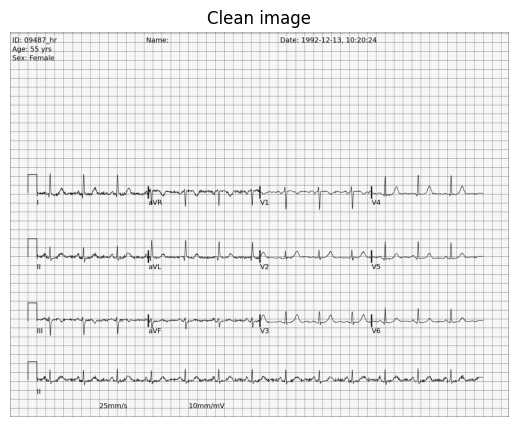

In [19]:
clean_img, clean_path = load_gray_image(selected_ecg_id, clean_scan)

print("ECG ID:", selected_ecg_id)
print("Clean path:", clean_path)
print("Shape:", clean_img.shape)

plt.figure(figsize=(12, 5))
plt.imshow(clean_img, cmap="gray")
plt.title("Clean image")
plt.axis("off")
plt.show()


## Step 2 - Add synthetic ink

We use the same synthetic idea as in the other notebooks.
The true synthetic ink mask is known.


Random seed: 19
True synthetic mask pixels: 336648


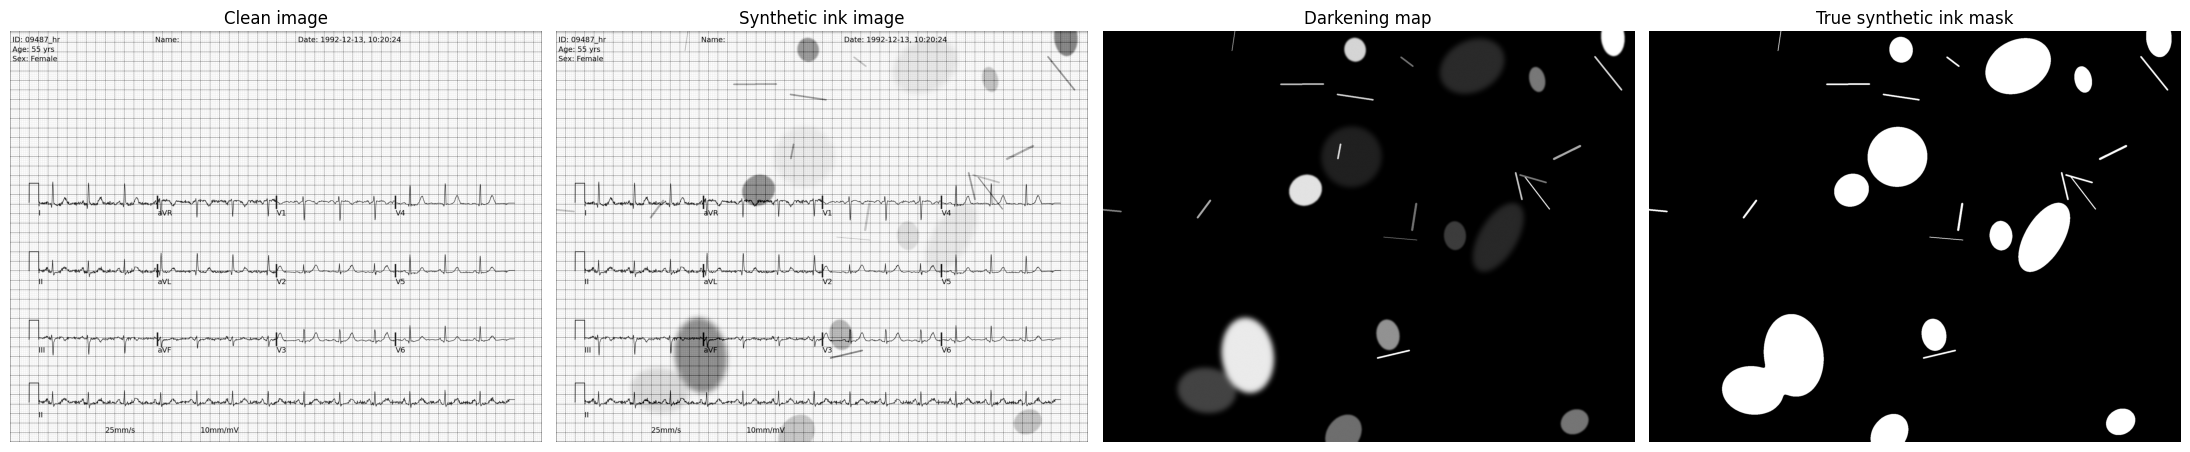

In [20]:
synthetic_ink, darkening_map, true_ink_mask = generate_random_ink_from_clean(
    clean_img,
    seed=RANDOM_SEED,
    n_strokes=N_STROKES,
    n_blobs=N_BLOBS,
    n_smudges=N_SMUDGES,
)

print("Random seed:", RANDOM_SEED)
print("True synthetic mask pixels:", int(true_ink_mask.sum()))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(clean_img, cmap="gray")
axes[0].set_title("Clean image")
axes[0].axis("off")
axes[1].imshow(synthetic_ink, cmap="gray")
axes[1].set_title("Synthetic ink image")
axes[1].axis("off")
axes[2].imshow(darkening_map, cmap="gray")
axes[2].set_title("Darkening map")
axes[2].axis("off")
axes[3].imshow(true_ink_mask, cmap="gray")
axes[3].set_title("True synthetic ink mask")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## Step 3 - Simple derivative filter `Kx`

This is a basic first derivative in the x direction.
It reacts to horizontal intensity change.


Kx mean |delta| on ink mask   : 0.008876
Kx mean |delta| outside mask  : 0.000252
Kx ink / outside ratio        : 35.22


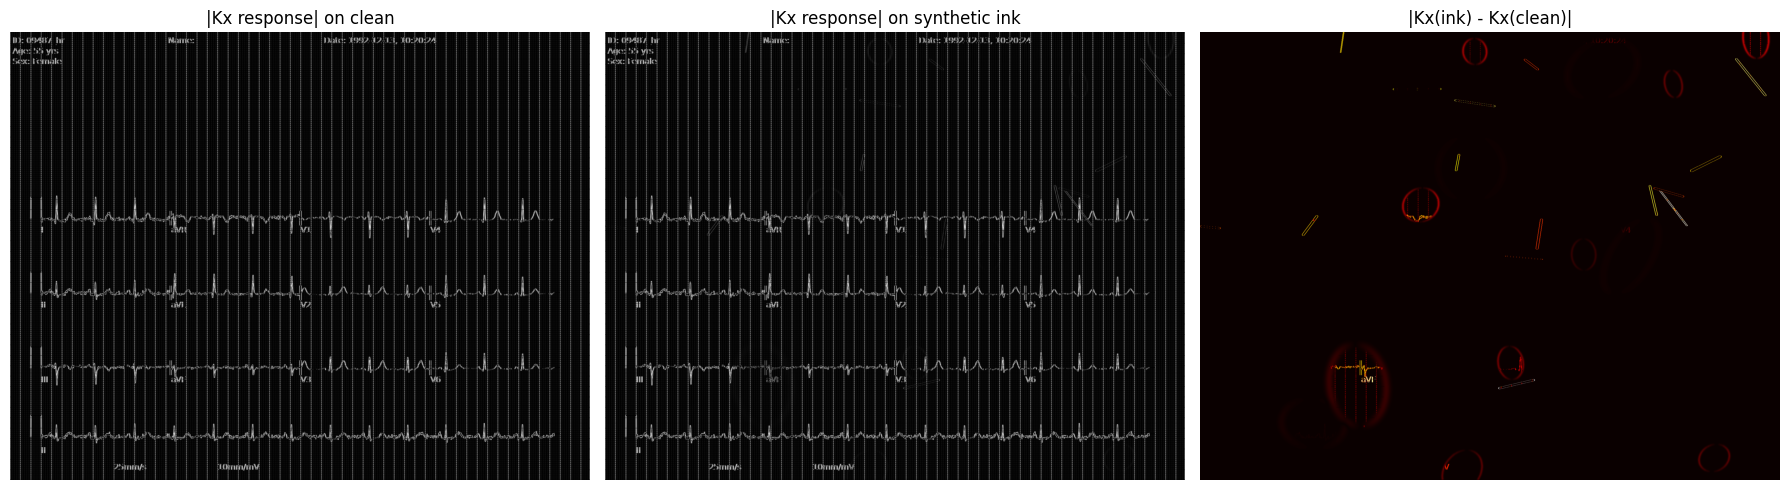

In [21]:
kx_clean = apply_kx_filter(clean_img)
kx_ink = apply_kx_filter(synthetic_ink)
kx_diff = response_difference(kx_clean, kx_ink)
kx_summary = summarize_response_diff("Kx", kx_diff, true_ink_mask)

print("Kx mean |delta| on ink mask   :", f"{kx_summary['ink_mean']:.6f}")
print("Kx mean |delta| outside mask  :", f"{kx_summary['outside_mean']:.6f}")
print("Kx ink / outside ratio        :", f"{kx_summary['ratio']:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(normalize_for_display(np.abs(kx_clean)), cmap="gray")
axes[0].set_title("|Kx response| on clean")
axes[0].axis("off")
axes[1].imshow(normalize_for_display(np.abs(kx_ink)), cmap="gray")
axes[1].set_title("|Kx response| on synthetic ink")
axes[1].axis("off")
axes[2].imshow(normalize_for_display(kx_diff), cmap="hot")
axes[2].set_title("|Kx(ink) - Kx(clean)|")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Step 4 - Sobel filter

Here we use the Sobel magnitude.
So the response combines x and y gradients.


Sobel mean |delta| on ink mask  : 0.048409
Sobel mean |delta| outside mask : 0.001469
Sobel ink / outside ratio       : 32.95


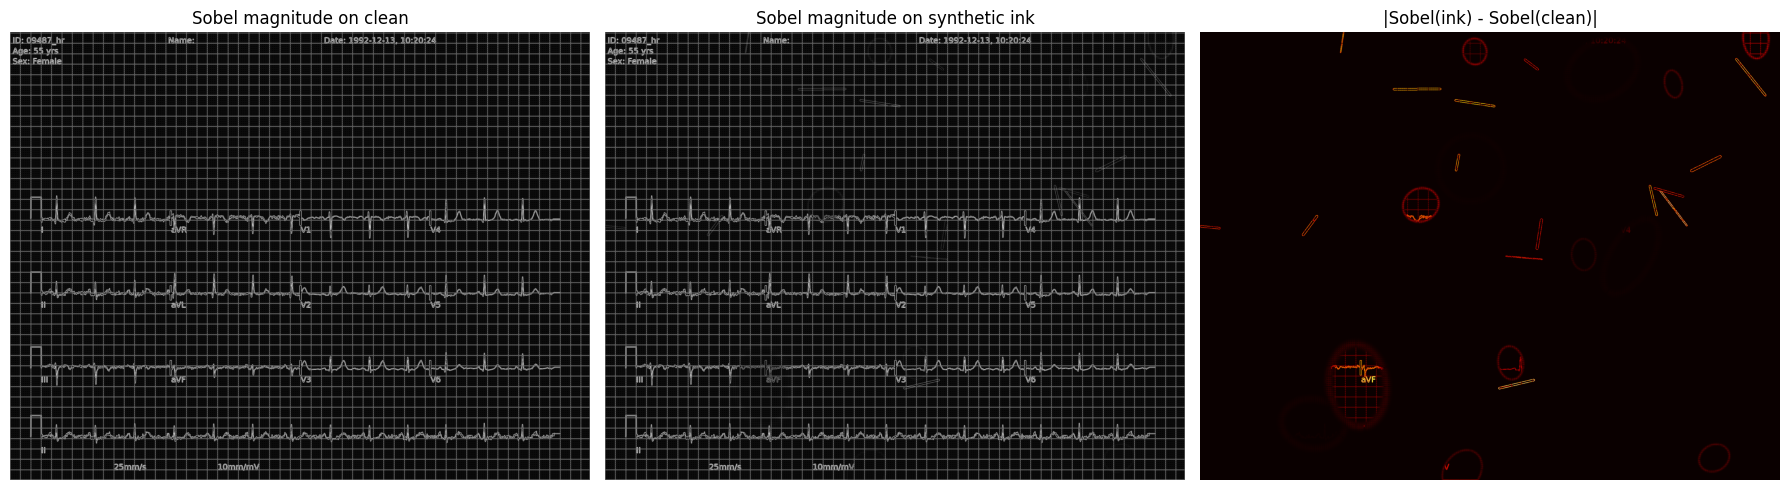

In [22]:
sobel_clean = apply_sobel_magnitude(clean_img)
sobel_ink = apply_sobel_magnitude(synthetic_ink)
sobel_diff = response_difference(sobel_clean, sobel_ink)
sobel_summary = summarize_response_diff("Sobel", sobel_diff, true_ink_mask)

print("Sobel mean |delta| on ink mask  :", f"{sobel_summary['ink_mean']:.6f}")
print("Sobel mean |delta| outside mask :", f"{sobel_summary['outside_mean']:.6f}")
print("Sobel ink / outside ratio       :", f"{sobel_summary['ratio']:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(normalize_for_display(sobel_clean), cmap="gray")
axes[0].set_title("Sobel magnitude on clean")
axes[0].axis("off")
axes[1].imshow(normalize_for_display(sobel_ink), cmap="gray")
axes[1].set_title("Sobel magnitude on synthetic ink")
axes[1].axis("off")
axes[2].imshow(normalize_for_display(sobel_diff), cmap="hot")
axes[2].set_title("|Sobel(ink) - Sobel(clean)|")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Step 5 - Laplacian filter

This is a second derivative.
It reacts to rapid local intensity change in all directions.


Laplacian mean |delta| on ink mask  : 0.043310
Laplacian mean |delta| outside mask : 0.001299
Laplacian ink / outside ratio       : 33.35


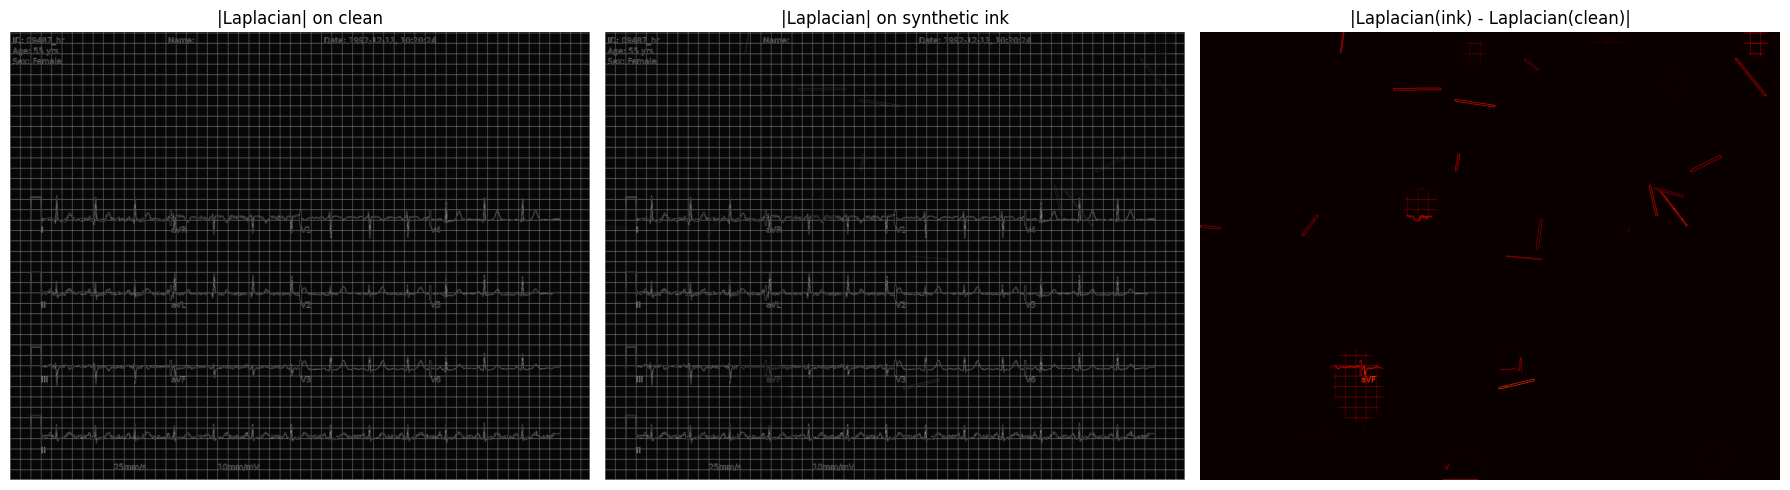

In [23]:
lap_clean = apply_laplacian(clean_img)
lap_ink = apply_laplacian(synthetic_ink)
lap_diff = response_difference(lap_clean, lap_ink)
lap_summary = summarize_response_diff("Laplacian", lap_diff, true_ink_mask)

print("Laplacian mean |delta| on ink mask  :", f"{lap_summary['ink_mean']:.6f}")
print("Laplacian mean |delta| outside mask :", f"{lap_summary['outside_mean']:.6f}")
print("Laplacian ink / outside ratio       :", f"{lap_summary['ratio']:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(normalize_for_display(np.abs(lap_clean)), cmap="gray")
axes[0].set_title("|Laplacian| on clean")
axes[0].axis("off")
axes[1].imshow(normalize_for_display(np.abs(lap_ink)), cmap="gray")
axes[1].set_title("|Laplacian| on synthetic ink")
axes[1].axis("off")
axes[2].imshow(normalize_for_display(lap_diff), cmap="hot")
axes[2].set_title("|Laplacian(ink) - Laplacian(clean)|")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Step 6 - Final comparison table

We compare the three filters by the change in response.

- high value on the ink mask means the filter reacts to the stain
- low value outside the mask means the filter changes less on non-ink regions
- a higher ratio is better for separation


Kx
  mean |delta| on ink     : 0.008876
  mean |delta| outside    : 0.000252
  ink / outside ratio     : 35.22
  global mean |delta|     : 0.001028
Laplacian
  mean |delta| on ink     : 0.043310
  mean |delta| outside    : 0.001299
  ink / outside ratio     : 33.35
  global mean |delta|     : 0.005080
Sobel
  mean |delta| on ink     : 0.048409
  mean |delta| outside    : 0.001469
  ink / outside ratio     : 32.95
  global mean |delta|     : 0.005694


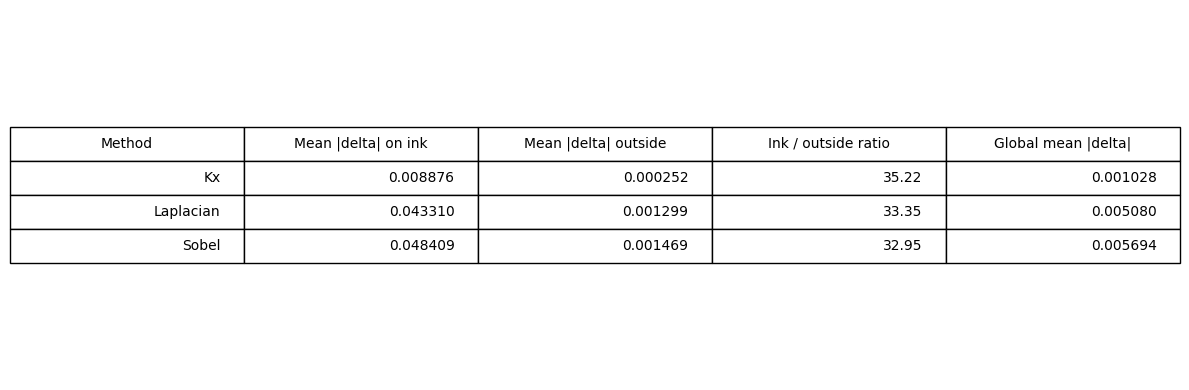

In [24]:
rows = [kx_summary, sobel_summary, lap_summary]
rows = sorted(rows, key=lambda row: row["ratio"], reverse=True)

for row in rows:
    print(row["method"])
    print("  mean |delta| on ink     :", f"{row['ink_mean']:.6f}")
    print("  mean |delta| outside    :", f"{row['outside_mean']:.6f}")
    print("  ink / outside ratio     :", f"{row['ratio']:.2f}")
    print("  global mean |delta|     :", f"{row['global_mean']:.6f}")

draw_results_table(rows)


## Conclusion

Saved result on `11842146`:
- `Kx` has the best separation ratio: `35.22`.
- `Laplacian` is next: `33.35`.
- `Sobel` is close: `32.95`.

`Kx` changes the least outside the mask, so it is the cleanest detector in this run.
`Sobel` and `Laplacian` react more strongly overall, but they also react more outside the ink region.
These filters are useful for detection, not as direct restoration methods.
